In [611]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading the data

In [612]:
df = pd.read_csv('24_Coffee_Taste_Test.csv')
df.head()

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Raw data overview
## Shape and Data types
The dataset has 4042 rows and 57 columns of which 13 are floats and 44 are objects.

In [613]:
df.shape

(4042, 57)

In [614]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4042 entries, 0 to 4041
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   submission_id                 4042 non-null   object 
 1   age                           4011 non-null   object 
 2   cups                          3949 non-null   object 
 3   where_drink                   3972 non-null   object 
 4   brew                          3657 non-null   object 
 5   brew_other                    678 non-null    object 
 6   purchase                      710 non-null    object 
 7   purchase_other                31 non-null     object 
 8   favorite                      3980 non-null   object 
 9   favorite_specify              116 non-null    object 
 10  additions                     3959 non-null   object 
 11  additions_other               48 non-null     object 
 12  dairy                         1686 non-null   object 
 13  swe

## Null Counts

In [615]:
df.isnull().sum().sort_values()

submission_id                      0
age                               31
favorite                          62
where_drink                       70
additions                         83
style                             84
cups                              93
roast_level                      102
expertise                        104
caffeine                         125
strength                         126
coffee_a_bitterness              244
coffee_a_personal_preference     253
coffee_b_bitterness              262
coffee_a_acidity                 263
coffee_b_personal_preference     269
prefer_abc                       270
prefer_overall                   272
coffee_b_acidity                 275
coffee_d_bitterness              275
coffee_c_personal_preference     276
coffee_d_acidity                 277
coffee_d_personal_preference     278
coffee_c_bitterness              278
prefer_ad                        281
coffee_c_acidity                 291
brew                             385
w

## Basic Statistics

In [616]:
float_cols = df.select_dtypes(include=["float"]).columns.tolist()
df[float_cols].describe()

,expertise,coffee_a_bitterness,coffee_a_acidity,coffee_a_personal_preference,coffee_b_bitterness,coffee_b_acidity,coffee_b_personal_preference,coffee_c_bitterness,coffee_c_acidity,coffee_c_personal_preference,coffee_d_bitterness,coffee_d_acidity,coffee_d_personal_preference
count,3938.000000,3798.000000,3779.000000,3789.000000,3780.000000,3767.000000,3773.000000,3764.000000,3751.000000,3766.000000,3767.000000,3765.000000,3764.000000
mean,5.693499,2.141127,3.634824,3.310900,3.013228,2.223786,3.068646,3.071998,2.366836,3.064790,2.162729,3.858167,3.375930
std,1.948867,0.947163,0.982113,1.185953,0.992875,0.865389,1.113546,0.999267,0.921048,1.128431,1.081546,1.007973,1.452504
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,5.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,2.000000
50%,6.000000,2.000000,4.000000,3.000000,3.000000,2.000000,3.000000,3.000000,2.000000,3.000000,2.000000,4.000000,4.000000
75%,7.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,3.000000,5.000000,5.000000
max,10.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## Interesting columns
### favorite
This column denotes the subject's favorite type of coffee 

In [617]:
df.favorite.value_counts(dropna=False)

Pourover                            1084
Latte                                680
Regular drip coffee                  442
Cappuccino                           341
Espresso                             330
Cortado                              312
Americano                            249
Iced coffee                          156
Mocha                                118
Other                                114
Cold brew                            109
NaN                                   62
Blended drink (e.g. Frappuccino)      45
Name: favorite, dtype: int64

### gender
This column denotes the subject's gender

In [618]:
df.gender.value_counts(dropna=False)

Male                      2524
Female                     853
NaN                        519
Non-binary                 103
Prefer not to say           33
Other (please specify)      10
Name: gender, dtype: int64

### total_spend
This column denotes the range of money the subject spends on coffee per month

In [619]:
df.total_spend.value_counts(dropna=False)

$20-$40     1293
$40-$60     1050
NaN          531
<$20         427
$60-$80      387
$80-$100     223
>$100        131
Name: total_spend, dtype: int64

## age
This column denotes the age bracket of the subject

In [620]:
df.age.value_counts(dropna=False)


25-34 years old    1986
35-44 years old     960
18-24 years old     461
45-54 years old     302
55-64 years old     187
>65 years old        95
NaN                  31
<18 years old        20
Name: age, dtype: int64

### wfh
This column denotes whether the subject works from home / office.

In [621]:
df.wfh.value_counts(dropna=False)

I primarily work from home    1592
I primarily work in person    1049
I do a mix of both             883
NaN                            518
Name: wfh, dtype: int64

This column has a lot of missing values, but would be interesting to analyze with the column `where_drink`

### spent_equipment
This column denotes how much a subject has spent on equipment to brew coffee

In [622]:
df.spent_equipment.value_counts(dropna=False)

More than $1,000    780
$100-$300           750
$500-$1000          642
$300-$500           597
NaN                 536
$50-$100            310
Less than $20       239
$20-$50             188
Name: spent_equipment, dtype: int64

### cups
This column denotes the average cups of a coffee a subject drinks in a day.

In [623]:
df.cups.value_counts(dropna=False)

2              1663
1              1277
3               473
Less than 1     348
4               121
NaN              93
More than 4      67
Name: cups, dtype: int64

In [624]:
df.employment_status.value_counts(dropna=False)

Employed full-time    2708
NaN                    623
Student                221
Employed part-time     201
Unemployed             126
Retired                 85
Homemaker               78
Name: employment_status, dtype: int64

To conclude, the data has a lot of missing values, but it does not suffer from inconsistent formatting, outliers or duplicate values. So the only cleaning required is deciding what to do with the missing values

# Cleaning the data

### favorite
This column has only 62 missing values and over 10 categories.<br/> 
It would not make sense to impute a value here, since we cannot be certain what a subject's favorite coffee is.<br/>
Because there are very few missing values, we can safely drop them.

In [625]:
df = df.dropna(subset=["favorite"])
df.favorite.value_counts(dropna=False)

Pourover                            1084
Latte                                680
Regular drip coffee                  442
Cappuccino                           341
Espresso                             330
Cortado                              312
Americano                            249
Iced coffee                          156
Mocha                                118
Other                                114
Cold brew                            109
Blended drink (e.g. Frappuccino)      45
Name: favorite, dtype: int64

### gender
This column has over 500 missing values.<br/>
However, we can reasonably assume that the people who did not specify a gender, preferred not to share their gender. <br/>
So we fill the nan values in this column with `Prefer not to say`

In [626]:
df['gender'] = df['gender'].fillna('Prefer not to say')
df.gender.value_counts(dropna=False)

Male                      2524
Female                     853
Prefer not to say          490
Non-binary                 103
Other (please specify)      10
Name: gender, dtype: int64

### total_spend
Dropping the missing values, since we cannot reliably estimate how much people spend on coffee monthly

In [627]:
df = df.dropna(subset=["total_spend"])
df.total_spend.value_counts(dropna=False)

$20-$40     1293
$40-$60     1050
<$20         427
$60-$80      387
$80-$100     223
>$100        131
Name: total_spend, dtype: int64

### age
This column has very few missing values, and there is no reliable way to ascertain the age group for a subject, so we drop them.

In [628]:
df = df.dropna(subset=["age"])
df.age.value_counts(dropna=False)

25-34 years old    1794
35-44 years old     850
18-24 years old     384
45-54 years old     254
55-64 years old     148
>65 years old        68
<18 years old        13
Name: age, dtype: int64

## Deriving a new column `generation`
The column will denote the generation of a subject (Millenial, GenZ, etc..)<br/>
The column will be derived from the age ranges in the `age` column. It is important to note that the ranges in `age` and actual generation age ranges are slightly different so the generation demographic information will be a rough estimate.

In [629]:
generation_mapping = {
    "<18 years old": "Gen Z",
    "18-24 years old": "Gen Z",
    "25-34 years old": "Millennial",  
    "35-44 years old": "Millennial",
    "45-54 years old": "Gen X",
    "55-64 years old": "Boomer",  
    ">65 years old": "Boomer",
}

df['generation'] = df["age"].map(generation_mapping)
df['generation'].value_counts()

Millennial    2644
Gen Z          397
Gen X          254
Boomer         216
Name: generation, dtype: int64

### wfh
The category names are very long, so we shorten them to `Work from home`, `Work from office` and `Hybrid`

In [630]:
wfh_mapping = {
    "I primarily work from home": "Work from home",
    "I primarily work in person": "Work from office",
    "I do a mix of both": "Hybrid",
}

# Force Pandas to modify the column safely in place
df.loc[:, "wfh"] = df["wfh"].map(wfh_mapping).fillna(df["wfh"])

In [631]:
df.wfh.value_counts(dropna=False)

Work from home      1562
Work from office    1036
Hybrid               867
NaN                   46
Name: wfh, dtype: int64

This column has a significant amount of missing values.<br/>
We can impute some values using the `employment_status` column

In [632]:
df.employment_status.value_counts(dropna=False)

Employed full-time    2678
Student                219
Employed part-time     196
NaN                    141
Unemployed             122
Retired                 79
Homemaker               76
Name: employment_status, dtype: int64

We can assume that people who have `employment_status` value as `Unemployed`, `Retired`, `Student` do not work so we can create a new status for them as `Unemployed`.<br/>
People with the `Homemaker` status are assumed to be working from home.

In [633]:
# 1. Fill Unemployed, Retired, and Students as 'Unemployed'
df.loc[
    df["wfh"].isna()
    & df["employment_status"].isin(["Unemployed", "Retired", "Student"]),
    "wfh",
] = "Unemployed"

# 2. Fill Homemakers as 'Work from home'
df.loc[df["wfh"].isna() & (df["employment_status"] == "Homemaker"), "wfh"] = (
    "Work from home"
)

df.wfh.value_counts(dropna=False)

Work from home      1568
Work from office    1036
Hybrid               867
Unemployed            33
NaN                    7
Name: wfh, dtype: int64

In [634]:
df = df.dropna(subset=["wfh"])
df.wfh.value_counts(dropna=False)

Work from home      1568
Work from office    1036
Hybrid               867
Unemployed            33
Name: wfh, dtype: int64

### spent_equipment
Dropping the missing values, since we cannot reliably estimate how much people spend on coffee equipment

In [635]:
df = df.dropna(subset=["spent_equipment"])
df.spent_equipment.value_counts(dropna=False)

More than $1,000    769
$100-$300           741
$500-$1000          628
$300-$500           587
$50-$100            308
Less than $20       235
$20-$50             186
Name: spent_equipment, dtype: int64

### cups
Dropping the missing values, since we cannot reliably estimate how much coffee people drink per day

In [636]:
df = df.dropna(subset=["cups"])
df.cups.value_counts(dropna=False)

2              1458
1              1132
3               407
Less than 1     296
4               105
More than 4      56
Name: cups, dtype: int64

In [637]:
new_df = df[['favorite', 'gender', 'total_spend', 'age', 'wfh', 'spent_equipment', 'cups', 'generation']]
new_df.head()

,favorite,gender,total_spend,age,wfh,spent_equipment,cups,generation
34,Regular drip coffee,Male,$20-$40,45-54 years old,Work from home,$500-$1000,2,Gen X
41,Pourover,Male,$40-$60,25-34 years old,Hybrid,$50-$100,2,Millennial
42,Iced coffee,Male,$20-$40,35-44 years old,Work from office,$100-$300,1,Millennial
43,Pourover,Male,$40-$60,45-54 years old,Work from home,$300-$500,More than 4,Gen X
46,Cappuccino,Male,$60-$80,35-44 years old,Hybrid,"More than $1,000",2,Millennial


In [638]:
new_df.shape

(3454, 8)

# Visualizations 


Here, we compare how working conditions affect the amount of money people spend on equipment to brew coffee at home and cross compare it to how much they typically spend on buying coffee monthly.

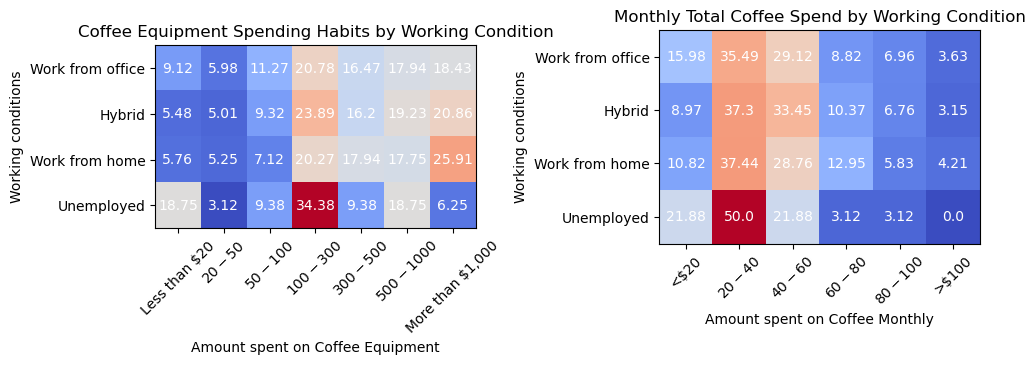

In [639]:
# https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
spending_order = [
    "Less than $20",
    "$20-$50",
    "$50-$100",
    "$100-$300",
    "$300-$500",
    "$500-$1000",
    "More than $1,000",
]

wfh_order = ["Work from office", "Hybrid", "Work from home", "Unemployed"]

# Since there is a huge gap between category counts, we normalize data across the row
# This makes data proportional (between 0% - 100%) across the rows, reducing skew
heatmap_data = (
    pd.crosstab(new_df["wfh"], new_df["spent_equipment"], normalize="index") * 100
)

heatmap_data = (
    heatmap_data.reindex(index=wfh_order, columns=spending_order).fillna(0).to_numpy()
)
heatmap_data = np.round(heatmap_data, decimals=2)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
im = ax[0].imshow(heatmap_data, cmap="coolwarm")
# Show all ticks and label them with the respective list entries
ax[0].set_xticks(range(len(spending_order)), labels=spending_order, rotation=45)
ax[0].set_yticks(range(len(wfh_order)), labels=wfh_order)

# Create colorbar
#cbar = ax[1].figure.colorbar(im, ax=ax)
#cbar.ax.set_ylabel("", rotation=-90, va="bottom")

#Loop over data dimensions and create text annotations.
for i in range(len(wfh_order)):
    for j in range(len(spending_order)):
        text = ax[0].text(j, i, heatmap_data[i, j],
                       ha="center", va="center", color="w")

ax[0].set_title("Coffee Equipment Spending Habits by Working Condition")
ax[0].set_xlabel('Amount spent on Coffee Equipment')
ax[0].set_ylabel('Working conditions')

# Second heatmap
total_spend_order = [
    "<$20",
    "$20-$40",
    "$40-$60",
    "$60-$80",
    "$80-$100",
    ">$100"
]

# Since there is a huge gap between category counts, we normalize data across the row
# This makes data proportional (between 0% - 100%) across the rows, reducing skew
other_heatmap_data = (
    pd.crosstab(new_df["wfh"], new_df["total_spend"], normalize="index") * 100
)

other_heatmap_data = other_heatmap_data.reindex(
    index=wfh_order, columns=total_spend_order
).fillna(0).to_numpy()
other_heatmap_data = np.round(other_heatmap_data, decimals=2)

im = ax[1].imshow(other_heatmap_data, cmap="coolwarm")
# Show all ticks and label them with the respective list entries
ax[1].set_xticks(range(len(total_spend_order)), labels=total_spend_order, rotation=45)
ax[1].set_yticks(range(len(wfh_order)), labels=wfh_order)

# Loop over data dimensions and create text annotations.
for i in range(len(wfh_order)):
    for j in range(len(total_spend_order)):
        text = ax[1].text(
            j, i, other_heatmap_data[i, j], ha="center", va="center", color="w"
        )

ax[1].set_title("Monthly Total Coffee Spend by Working Condition")
ax[1].set_xlabel("Amount spent on Coffee Monthly")
ax[1].set_ylabel("Working conditions")
fig.tight_layout()
plt.show()

We can see that:<br/>
+ people who work from home tend to spend the most on coffee equipment (~ 25% spend more than $1000).<br/>
+ people who work from the office or hybrid also tend to typically spend about $100-300 on equipment.<br/>
+ The `Unemployed` category has the most varied spend, but this can be accounted for by the demographics (students might spend < $20, temporarily unemployed people or retired people might have already invested in equipment previously which would explain the higher spend in $100-$300 and $500-$1000 range)<br/>
Overall, people tend to spend a significant amount of money on coffee equipment regardless of their working conditions
<br/><br/>
In the second graph, we can see that, in general people spend <$60 monthly on coffee even if they have spent a lot of coffee equipment<br/>



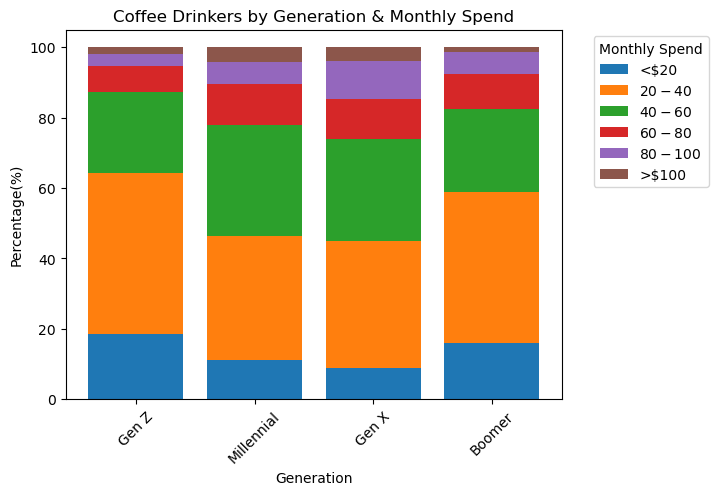

In [640]:
generation_order = ["Gen Z", "Millennial", "Gen X", "Boomer"]

cups_order = [
    "Less than 1",
    "1",
    "2",
    "3",
    "4",
    "More than 4"
]

#values = new_df.groupby(by=["age", "cups"])[['age', 'cups']].value_counts()
#new_index = pd.MultiIndex.from_product(
#    [age_order, cups_order], names=["Age group", "Daily cups of coffee"]
#)
#values = values.reindex(new_index).fillna(0).to_numpy().reshape((7,6))
values = pd.crosstab(new_df["generation"], new_df["total_spend"], normalize='index')*100
values = values.reindex(index=generation_order, columns=total_spend_order).fillna(0).to_numpy()

fig, ax = plt.subplots()
ax.set_xticks(range(len(generation_order)), labels=generation_order, rotation=45)
#ax.set_yticks(range(len(cups_order)), labels=cups_order)
bottom_values = np.zeros(len(generation_order))

for i, subcategory in enumerate(total_spend_order):
    ax.bar(generation_order, values[:, i], bottom=bottom_values, label=subcategory)
    bottom_values += values[:, i]

ax.set_ylabel("Percentage(%)")
ax.set_xlabel('Generation')
ax.set_title("Coffee Drinkers by Generation & Monthly Spend")
ax.legend(title="Monthly Spend", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

We can see that ~30% `Gen Z` people tend to spend `$20-$40`, while `~15%` spend `$40-$60`, but this ratio moves in the other direction with age, maybe because people have more disposable income?
It goes back to the initial observation for `Boomer`, might be because older people give up on drinking coffee as often

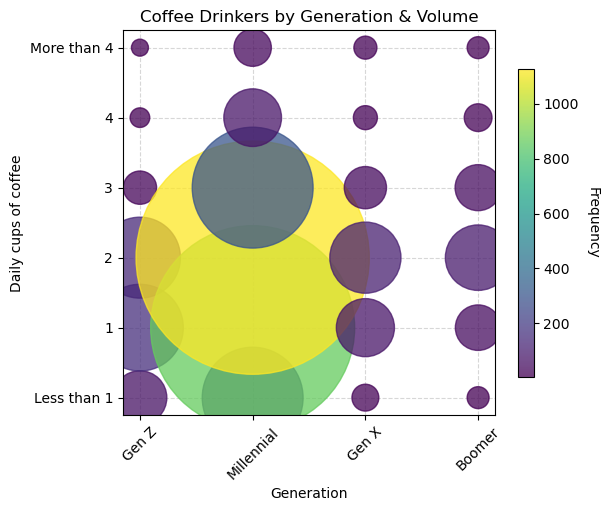

In [641]:
values = new_df.groupby(by=["generation", "cups"])[
    ["generation", "cups"]
].value_counts()
new_index = pd.MultiIndex.from_product(
   [generation_order, cups_order], names=["Generation", "Daily cups of coffee"] 
)
# values = values.reindex(new_index).fillna(0).to_numpy().reshape((7,6))
values = values.reindex(new_index).fillna(0).reset_index(name="Count")

fig, ax = plt.subplots(figsize=(6, 5))

bubble = ax.scatter(
    x=values["Generation"],
    y=values["Daily cups of coffee"],
    s=values["Count"] * 25,  # Control marker size (area)
    c=values["Count"],  # Map bubble color to values
    cmap="viridis",
    alpha=0.75,  # Blend overlapping markers
    #edgecolors="black",
)

# 4. Add details and colorbar
ax.set_xticks(range(len(generation_order)), labels=generation_order, rotation=45)
ax.set_title("Coffee Drinkers by Generation & Volume")
ax.set_xlabel("Generation")
ax.set_ylabel("Daily cups of coffee")
ax.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)  # Move gridlines behind the bubbles

# Add colorbar indicator
cbar = fig.colorbar(bubble, ax=ax, shrink=0.8)
cbar.set_label("Frequency", rotation=270, labelpad=15)

plt.show()

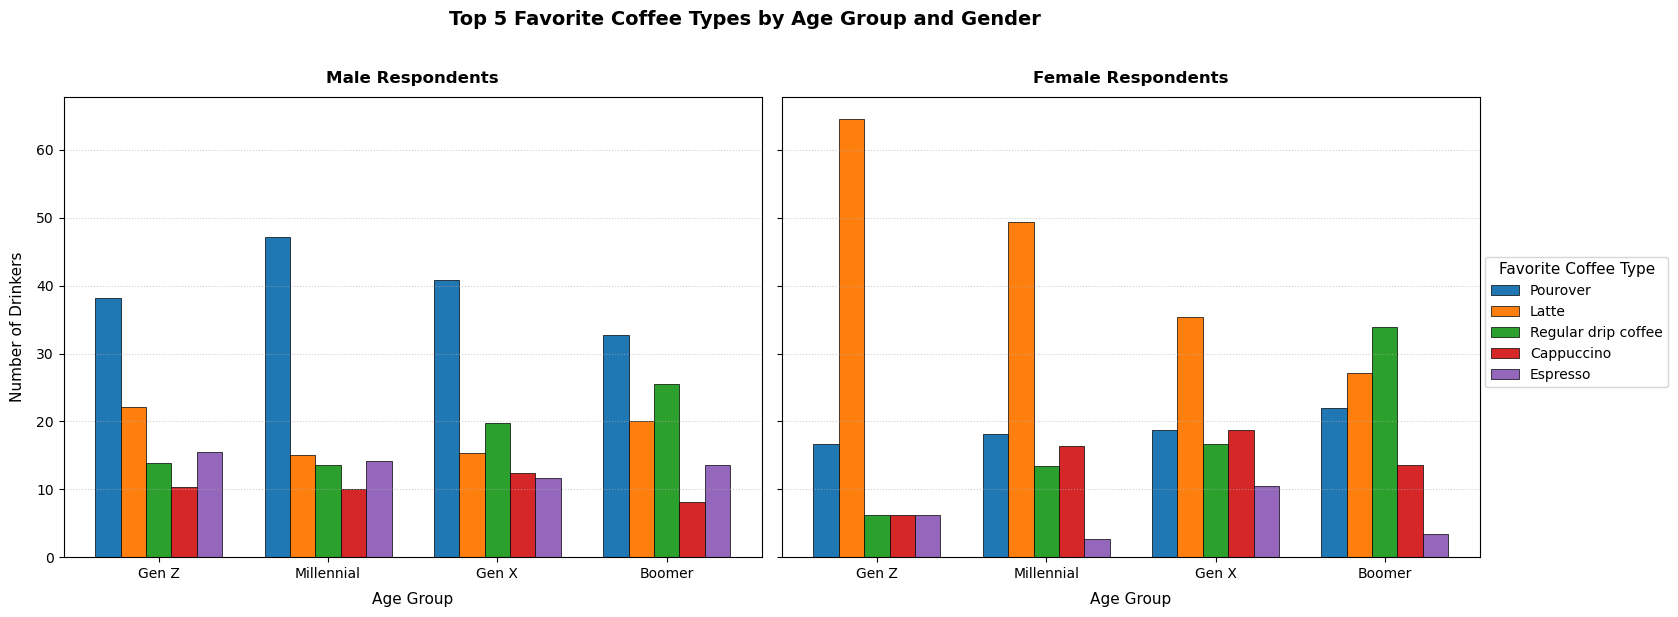

In [642]:
top_5_coffees = ["Pourover", "Latte", "Regular drip coffee", "Cappuccino", "Espresso"]
genders = ["Male", "Female"]

filtered_df = new_df[new_df["favorite"].isin(top_5_coffees) & new_df["gender"].isin(genders)]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)
x_indices = np.arange(len(generation_order))  
bar_width = 0.15                      
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'] # 5 distinct colors

for ax_idx, gender in enumerate(genders):
    ax = axes[ax_idx]
    
    # Filter dataset for the current gender
    gender_df = filtered_df[filtered_df['gender'] == gender]
    
    crosstab = pd.crosstab(gender_df['generation'], gender_df['favorite'], normalize='index')*100
    crosstab = crosstab.reindex(index=generation_order, columns=top_5_coffees).fillna(0)
    
    # Plot each coffee type as a shifted bar
    for coffee_idx, coffee in enumerate(top_5_coffees):
        # Shift the X position of each bar so they line up sequentially
        shifted_x = x_indices + (coffee_idx * bar_width) - (len(top_5_coffees) * bar_width / 2) + (bar_width / 2)
        
        ax.bar(
            shifted_x, 
            crosstab[coffee], 
            width=bar_width, 
            label=coffee if ax_idx == 0 else "",
            color=colors[coffee_idx],
            edgecolor='black',
            linewidth=0.5
        )
    
    # Formatting specific to each subplot panel
    ax.set_xticks(x_indices)
    ax.set_xticklabels(generation_order)
    ax.set_xlabel("Age Group", fontsize=11, labelpad=8)
    ax.set_title(f"{gender} Respondents", fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# 5. Global Layout Styling & Legends
axes[0].set_ylabel("Number of Drinkers", fontsize=11, labelpad=8)

# Place a single shared clean legend box completely outside the graph margins
fig.legend(title="Favorite Coffee Type", loc='center right', bbox_to_anchor=(1.12, 0.5), title_fontsize=11)

fig.suptitle("Top 5 Favorite Coffee Types by Age Group and Gender", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()